In [10]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [11]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [12]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [13]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [14]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)

In [15]:
def create_sliding_window_full_df(
        df,
        target_col="EUR/MWh",
        window_days=7,
        forecast_horizon=1,
        da_cols=["Load_DA", "Solar_DA", "Wind_DA"],
        rt_cols=["EUR/MWh", "Load_RT", "Solar_RT", "Wind_RT"],
        cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"]
    ):

    df = df.sort_values("Date").reset_index(drop=True)
    hours = 24
    window_size = window_days * hours
    n = len(df)

    rows = []

    for i in range(window_size, n - forecast_horizon):

        row_date = df.loc[i, "Date"]

        # ---- Past windows for each RT column ----
        window_data = {}
        for col in rt_cols:
            window = df.loc[i-window_size:i-1, col].values.astype(float)
            window_data[col] = window    # <-- DIRECT ARRAY, NO LIST

        # ---- Target ----
        y_t = df.loc[i + forecast_horizon - 1, target_col]

        # ---- Previous day price ----
        y_1d = df.loc[i - hours, target_col] if i - hours >= 0 else np.nan

        # ---- Previous week price ----
        y_7d = df.loc[i - 7 * hours, target_col] if i - 7 * hours >= 0 else np.nan

        # ---- Day-ahead scalar values ----
        da_data = {col: df.loc[i, col] for col in da_cols}

        # ---- Cyclic features ----
        cyc_data = {col: df.loc[i, col] for col in cyc_cols}

        # ---- Build row ----
        row = {
            "Date": row_date,
            "y": y_t,
            "y_1d": y_1d,
            "y_7d": y_7d,
        }
        row.update(window_data)
        row.update(da_data)
        row.update(cyc_data)

        rows.append(row)

    # Final DF
    out_df = pd.DataFrame(rows)
    return out_df


In [16]:
import numpy as np
import pandas as pd

def create_sliding_window_numpy(
        df,
        target_col="EUR/MWh",
        window_days=7,
        forecast_horizon=1,
        rt_cols=["EUR/MWh", "Load_RT", "Solar_RT", "Wind_RT"],
        rt_cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"],
        da_cols=["Load_DA", "Solar_DA", "Wind_DA"],
        da_cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"]
    ):

    df = df.sort_values("Date").reset_index(drop=True)
    hours = 24
    window_size = window_days * hours
    n = len(df)

    # ---- Storage ----
    X_rt_list = []
    X_rt_cyc_list = []
    X_da_list = []
    X_da_cyc_list = []
    y_list = []
    y1_list = []
    y7_list = []
    dates = []

    for i in range(window_size, n - forecast_horizon):

        dates.append(df.loc[i, "Date"])

        # =========================================
        # 1️⃣  REAL-TIME WINDOW   (unchanged)
        # =========================================
        rt_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                    for col in rt_cols]
        X_rt_list.append(np.stack(rt_stack, axis=1))

        rt_cyc_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                        for col in rt_cyc_cols]
        X_rt_cyc_list.append(np.stack(rt_cyc_stack, axis=1))

        # =========================================
        # 2️⃣  DAY-AHEAD (H-hour vector)
        # =========================================
        da_block     = df.loc[i:i+forecast_horizon-1, da_cols].values.astype(float)
        da_cyc_block = df.loc[i:i+forecast_horizon-1, da_cyc_cols].values.astype(float)

        X_da_list.append(da_block)         # shape (H, n_da)
        X_da_cyc_list.append(da_cyc_block) # shape (H, n_da_cyc)

        # =========================================
        # 3️⃣  TARGETS (H-hour vector)
        # =========================================
        y_list.append(
            df.loc[i:i+forecast_horizon-1, target_col].values.astype(float)
        )

        y1_list.append(
            df.loc[i-hours:i-hours+forecast_horizon-1, target_col].values.astype(float)
        )

        y7_list.append(
            df.loc[i-7*hours:i-7*hours+forecast_horizon-1, target_col].values.astype(float)
        )

    # ----------- Convert to numpy arrays --------------
    X_rt       = np.array(X_rt_list)       # (N, window, n_rt)
    X_rt_cyc   = np.array(X_rt_cyc_list)   # (N, window, n_rt_cyc)
    X_da       = np.array(X_da_list)       # (N, H, n_da)
    X_da_cyc   = np.array(X_da_cyc_list)   # (N, H, n_da_cyc)
    y          = np.array(y_list)          # (N, H)
    y_1d       = np.array(y1_list)         # (N, H)
    y_7d       = np.array(y7_list)         # (N, H)
    dates      = np.array(dates)

    # ---- Merge RT windows ----
    X_rt_full = np.concatenate([X_rt, X_rt_cyc], axis=2)  # (N, window, n_rt+n_rt_cyc)

    # ---- Merge DA blocks ----
    X_da_full = np.concatenate([X_da, X_da_cyc], axis=2)  # (N, H, n_da+n_da_cyc)

    # =====================================
    # FEATURE MAP (for normalization)
    # =====================================
    feature_map = {
        "rt_cols": rt_cols,
        "rt_cyc_cols": rt_cyc_cols,
        "rt_window_features": {
            "start_idx": 0,
            "end_idx": len(rt_cols)-1
        },
        "rt_cyclic_features": {
            "start_idx": len(rt_cols),
            "end_idx": len(rt_cols)+len(rt_cyc_cols)-1
        },
        "da_cols": da_cols,
        "da_cyc_cols": da_cyc_cols,
        "da_indices": {
            "start_idx": 0,
            "end_idx": len(da_cols)-1
        },
        "da_cyc_indices": {
            "start_idx": len(da_cols),
            "end_idx": len(da_cols)+len(da_cyc_cols)-1
        },
        "forecast_horizon": forecast_horizon
    }

    return X_rt_full, X_da_full, y, y_1d, y_7d, dates, feature_map


In [17]:
X_rt, X_da, y, y_1d, y_7d, dates, feature_map = create_sliding_window_numpy(all_data,
                                                                            target_col="EUR/MWh",
                                                                            window_days=7,
                                                                            forecast_horizon=24)

In [18]:
print("Shapes")
print("X_rt:", X_rt.shape)
print("X_da:", X_da.shape)
print("y:", y.shape)
print("y_1d:", y_1d.shape)
print("y_7d:", y_7d.shape)

Shapes
X_rt: (51955, 168, 10)
X_da: (51955, 24, 9)
y: (51955, 24)
y_1d: (51955, 24)
y_7d: (51955, 24)


In [19]:
def month_based_split_np(
        X_rt,
        X_da,
        y,
        y_1d,
        y_7d,
        dates,
        features_map,
        train_ratio=0.6,
        dev_ratio=0.2,
        seed=42
    ):
    """
    Month-based split for NumPy-array datasets.
    """

    # --- Convert dates to pandas for easy month extraction ---
    dates_pd = pd.to_datetime(dates)
    yearmonth = dates_pd.to_period("M")

    # --- Unique months ---
    all_months = np.array(yearmonth.unique())
    n_months = len(all_months)

    # --- Shuffle months ---
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(all_months)

    # --- Split ---
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio * n_months)

    train_m = shuffled[:n_train]
    dev_m   = shuffled[n_train : n_train+n_dev]
    test_m  = shuffled[n_train+n_dev :]

    # --- Boolean masks on rows ---
    mask_train = yearmonth.isin(train_m)
    mask_dev   = yearmonth.isin(dev_m)
    mask_test  = yearmonth.isin(test_m)

    # --- Helper to index all arrays ---
    def select(mask):
        return (
            X_rt[mask],
            X_da[mask],
            y[mask],
            y_1d[mask],
            y_7d[mask],
            dates[mask]
        )

    Xrt_tr, Xda_tr, y_tr, y1d_tr, y7d_tr, d_tr = select(mask_train)
    Xrt_de, Xda_de, y_de, y1d_de, y7d_de, d_de = select(mask_dev)
    Xrt_te, Xda_te, y_te, y1d_te, y7d_te, d_te = select(mask_test)

    return {
        "train": (Xrt_tr, Xda_tr, y_tr, y1d_tr, y7d_tr, d_tr),
        "dev":   (Xrt_de, Xda_de, y_de, y1d_de, y7d_de, d_de),
        "test":  (Xrt_te, Xda_te, y_te, y1d_te, y7d_te, d_te),
        "months": {
            "train": train_m,
            "dev": dev_m,
            "test": test_m
        },
        "feature_map": features_map
    }


In [20]:
splits = month_based_split_np(
    X_rt, X_da, y, y_1d, y_7d, dates, feature_map
)
Xrt_train, Xda_train, y_train, y1d_train, y7d_train, dates_train = splits["train"]
Xrt_dev,   Xda_dev,   y_dev,   y1d_dev,   y7d_dev,   dates_dev   = splits["dev"]
Xrt_test,  Xda_test,  y_test,  y1d_test,  y7d_test,  dates_test  = splits["test"]

features_map = splits["feature_map"]


In [21]:

df_price  = all_data[["Time","EUR/MWh"]]
df_da_load = all_data[["Time","Load_DA"]]
df_da_ren  = all_data[["Time","Solar_DA","Wind_DA"]]
df_rt_load = all_data[["Time","Load_RT"]]
df_rt_ren  = all_data[["Time","Solar_RT","Wind_RT"]]
for df in [df_price, df_da_load, df_da_ren, df_rt_load, df_rt_ren]:
    df["Date"] = pd.to_datetime(df["Time"], utc=True)
    df["YearMonth"] = df["Date"].dt.to_period("M")
train_months = splits["months"]["train"]  # <-- from your earlier split

df_price_tr  = df_price[df_price["YearMonth"].isin(train_months)]
df_da_load_tr = df_da_load[df_da_load["YearMonth"].isin(train_months)]
df_da_ren_tr  = df_da_ren[df_da_ren["YearMonth"].isin(train_months)]
df_rt_load_tr = df_rt_load[df_rt_load["YearMonth"].isin(train_months)]
df_rt_ren_tr  = df_rt_ren[df_rt_ren["YearMonth"].isin(train_months)]

stats_dict = {}

def compute_stats(df, cols, container, prefix=""):
    for c in cols:
        arr = df[c].astype(float).values
        container[prefix + c] = {
            "mean": float(np.nanmean(arr)),
            "std":  float(np.nanstd(arr) + 1e-8)
        }

# --- price y ---
compute_stats(df_price_tr, ["EUR/MWh"], stats_dict, prefix="price_")

# --- DA features ---
da_cols = ["Load_DA", "Solar_DA", "Wind_DA"]
compute_stats(df_da_load_tr.merge(df_da_ren_tr, on="Date"), da_cols, stats_dict, prefix="da_")

# --- RT features ---
rt_cols = ["Load_RT", "Solar_RT", "Wind_RT"]
compute_stats(df_rt_load_tr.merge(df_rt_ren_tr, on="Date"), rt_cols, stats_dict, prefix="rt_")




/tmp/ipykernel_3456/1433485796.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Time"], utc=True)
/tmp/ipykernel_3456/1433485796.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_3456/1433485796.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_3456/1433485796.py:7: SettingWithCopyWarning: 
A value i

In [22]:
def normalize_sets(
    Xrt, Xda, y,
    stats_dict,
    feature_map
):
    """
    Normalizes:
      - y using price stats
      - Xrt windowed features (EUR/MWh, Load_RT, Solar_RT, Wind_RT)
      - Xrt cyclic features untouched
      - Xda DA features
      - Xda cyclic features untouched
    """

    # --- Copies ---
    Xrt = Xrt.copy()
    Xda = Xda.copy()
    y   = y.copy()

    # --- Fix Xda shape: (N, 9) → (N,1,9) ---
    if Xda.ndim == 2:
        Xda = Xda[:, None, :]

    # -----------------------
    # Normalize y
    # -----------------------
    y_mean = stats_dict["price_EUR/MWh"]["mean"]
    y_std  = stats_dict["price_EUR/MWh"]["std"]
    y = (y - y_mean) / y_std

    # -----------------------
    # Normalize Xrt
    # -----------------------
    rt_cols = feature_map["rt_cols"]
    rt_cyc_cols = feature_map["rt_cyc_cols"]
    start_rt = feature_map["rt_window_features"]["start_idx"]
    end_rt   = feature_map["rt_window_features"]["end_idx"]

    # Windowed RT features (first 4 columns)
    for j, feat in enumerate(rt_cols):
        if feat == "EUR/MWh":
            mean, std = y_mean, y_std
        else:
            mean = stats_dict[f"rt_{feat}"]["mean"]
            std  = stats_dict[f"rt_{feat}"]["std"]

        Xrt[:, :, start_rt + j] = (Xrt[:, :, start_rt + j] - mean) / std

    # Cyclic RT: do nothing

    # -----------------------
    # Normalize Xda
    # -----------------------
    da_cols = feature_map["da_cols"]
    da_start = feature_map["da_indices"]["start_idx"]

    for j, feat in enumerate(da_cols):
        mean = stats_dict[f"da_{feat}"]["mean"]
        std  = stats_dict[f"da_{feat}"]["std"]

        Xda[:, 0, da_start + j] = (Xda[:, 0, da_start + j] - mean) / std

    # Cyclic DA: untouched

    return Xrt, Xda, y


In [23]:
Xrt_train_norm, Xda_train_norm, y_train_norm = normalize_sets(
    Xrt_train, Xda_train, y_train,
    stats_dict,
    feature_map
)

Xrt_dev_norm, Xda_dev_norm, y_dev_norm = normalize_sets(
    Xrt_dev, Xda_dev, y_dev,
    stats_dict,
    feature_map
)

Xrt_test_norm, Xda_test_norm, y_test_norm = normalize_sets(
    Xrt_test, Xda_test, y_test,
    stats_dict,
    feature_map
)

In [ ]:

# --- For y: make shape (N,1) ---
# y_train_norm = y_train_norm.reshape(-1, 1)
# y_dev_norm   = y_dev_norm.reshape(-1, 1)
# y_test_norm  = y_test_norm.reshape(-1, 1)


In [24]:
print("Shapes after normalization:")
print("Xrt_train_norm:", Xrt_train_norm.shape)
print("Xda_train_norm:", Xda_train_norm.shape)
print("y_train_norm:", y_train_norm.shape)

Shapes after normalization:
Xrt_train_norm: (31000, 168, 10)
Xda_train_norm: (31000, 24, 9)
y_train_norm: (31000, 24)


In [25]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [31]:
def evaluate_model(
    model,
    X_seq_np,
    X_dnn_np,
    y_np,
    y_np_1d,
    y_np_7d,
    stats_dict,
    batch_size,
    device="cpu"
):
    """
    Evaluation for MULTI-STEP forecasting (e.g. H=24).
    y_np must be shape (N, H)
    model outputs (N, H)
    """

    # ----------------------
    # Get normalization stats
    # ----------------------
    mean_FR = stats_dict["price_EUR/MWh"]["mean"]
    std_FR  = stats_dict["price_EUR/MWh"]["std"]

    model = model.to(device).eval()

    N = len(X_seq_np)
    preds_list = []

    # ----------------------
    # Predict
    # ----------------------
    with torch.no_grad():
        for i in range(0, N, batch_size):

            xb_seq = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)

            xb_dnn = (
                torch.from_numpy(X_dnn_np[i:i+batch_size]).float().to(device)
                if X_dnn_np is not None else None
            )

            out = model(xb_seq, xb_dnn)  # MUST be shape (batch, H)
            preds_list.append(out.cpu().numpy())

    predictions = np.concatenate(preds_list, axis=0)  # (N, H)

    # ----------------------
    # Denormalize
    # ----------------------
    predictions = predictions * std_FR + mean_FR
    y_np        = y_np        * std_FR + mean_FR

    # ----------------------
    # Metrics (multi-step)
    # ----------------------

    # MAE averaged over all 24 steps
    mae = np.mean(np.abs(predictions - y_np))

    # Median baseline (per horizon)
    median_val = np.median(y_np, axis=0)          # shape (H,)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae / mae_median

    # rMAE using naive (t-24)
    mae_model_1d = mae
    mae_naive_1d = np.mean(np.abs(y_np_1d - y_np))   # y_np_1d is (N,H)
    rMAE_1d = mae_model_1d / mae_naive_1d

    # rMAE using naive (t-168)
    mae_model_7d = mae
    mae_naive_7d = np.mean(np.abs(y_np_7d - y_np))
    rMAE_7d = mae_model_7d / mae_naive_7d

    print(f"MAE: {mae:.4f} | MAEm: {maem:.4f} | rMAE-1d: {rMAE_1d:.4f} | rMAE-7d: {rMAE_7d:.4f}")

    return {
        "predictions": predictions,
        "MAE": mae,
        "MAEm": maem,
        "rMAE_1d": rMAE_1d,
        "rMAE_7d": rMAE_7d
    }


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class RNN(nn.Module):
    def __init__(
        self,
        n_features,
        seq_len,
        output_dim,
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        use_batchnorm=True,
        leaky_alpha=0.1,
        future_dim=None,
        future_horizon=None
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_features = n_features
        self.output_dim = output_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.leaky_alpha = leaky_alpha

        # --- store dropout PROBABILITY ---
        self.dropout_p = dropout

        # --------------------- LSTM BRANCH ---------------------
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # Standard dropout layer for LSTM output and MLP
        self.dropout = nn.Dropout(dropout)

        # future_dense built lazily
        self.future_dim = future_dim
        self.future_horizon = future_horizon
        self.future_dense = None  

        # --------------------- FINAL MLP ---------------------
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_dim)

        if use_batchnorm:
            self.bn_lstm = nn.BatchNorm1d(hidden_size)
            self.bn_fc1 = nn.BatchNorm1d(hidden_size)


    # --------------------------------------------------------------
    def build_future_module(self):
        """Builds the DNN for future inputs once sizes are known."""
        fut_input_size = self.future_dim * self.future_horizon
        
        self.future_dense = nn.Sequential(
            nn.Linear(fut_input_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha),
            nn.Dropout(self.dropout_p),     # FIXED DROPOUT
            
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha)
        )

        # Move new module to same device as rest of model
        self.future_dense.to(next(self.parameters()).device)


    # --------------------------------------------------------------
    def forward(self, seq_x, future_x=None):
        """
        seq_x:    (B, seq_len, n_features)
        future_x: (B, future_horizon, future_dim)
        """

        device = next(self.parameters()).device
        seq_x = seq_x.to(device)
        if future_x is not None:
            future_x = future_x.to(device)

        # Build future network on-the-fly if needed
        if future_x is not None and self.future_dense is None:
            self.future_dim = future_x.shape[-1]
            self.future_horizon = future_x.shape[1]
            self.build_future_module()

        # --------------------- LSTM BRANCH ---------------------
        lstm_out, (h, _) = self.lstm(seq_x)
        h = h[-1]   # final hidden state (B, hidden_size)

        if self.use_batchnorm:
            h = self.bn_lstm(h)

        h = F.leaky_relu(h, negative_slope=self.leaky_alpha)
        h = self.dropout(h)

        # --------------------- FUTURE BRANCH ---------------------
        if future_x is not None and self.future_dense is not None:
            B = future_x.shape[0]
            fut = future_x.reshape(B, -1)
            fut = self.future_dense(fut)

            x = h + fut        # skip-like fusion
        else:
            x = h

        # --------------------- FINAL MLP ---------------------
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn_fc1(x)

        x = F.leaky_relu(x, negative_slope=self.leaky_alpha)
        x = self.dropout(x)

        return self.fc2(x)


In [53]:
def run_full_train(
    X_seq_train, X_dnn_train, y_train,
    X_seq_dev,   X_dnn_dev,   y_dev,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    use_batchnorm=True,
    leaky_alpha=0.1,
    learning_rate=1e-3,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_size=128,
    epochs=20,
    verbose_freq=1,
    device=device
):

    # -------------------------
    # Convert to tensors
    # -------------------------
    X_seq_train_t = torch.from_numpy(X_seq_train).float()
    X_seq_dev_t   = torch.from_numpy(X_seq_dev).float()

    X_dnn_train_t = torch.from_numpy(X_dnn_train).float() if X_dnn_train is not None else None
    X_dnn_dev_t   = torch.from_numpy(X_dnn_dev).float() if X_dnn_dev is not None else None

    y_train_t = torch.from_numpy(y_train).float()
    y_dev_t   = torch.from_numpy(y_dev).float()

    # -------------------------
    # Build model
    # -------------------------
    model = RNN(
        n_features=X_seq_train.shape[-1],
        seq_len=X_seq_train.shape[1],
        output_dim=y_train.shape[-1],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha
    ).to(device)

    if X_dnn_train is not None:
        model.future_dim = X_dnn_train.shape[-1]
        model.future_horizon = X_dnn_train.shape[1]
        model.build_future_module()

    # -------------------------
    # Optimizer / Scheduler / Loss
    # -------------------------
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # Cosine annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=learning_rate * 0.1
    )

    mae_loss = torch.nn.L1Loss()

    print("Model:")
    print(model)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)

    # -------------------------
    # Training history
    # -------------------------
    train_hist = []
    val_hist = []

    N = len(X_seq_train)

    # -------------------------
    # Training loop
    # -------------------------
    for epoch in range(epochs):

        model.train()
        perm = torch.randperm(N)

        train_loss_epoch = 0.0
        num_batches = 0

        for i in range(0, N, batch_size):

            idx = perm[i:i+batch_size]

            seq_b = X_seq_train_t[idx].to(device)
            dnn_b = X_dnn_train_t[idx].to(device) if X_dnn_train_t is not None else None
            y_b   = y_train_t[idx].to(device)

            preds = model(seq_b, dnn_b)
            loss = mae_loss(preds, y_b)

            # Optional L1 penalty
            if l1_lambda > 0:
                l1 = 0.0
                for p in model.parameters():
                    l1 += p.abs().sum()
                loss += l1_lambda * l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            num_batches += 1

        train_loss_epoch /= num_batches
        train_hist.append(train_loss_epoch)

        # -------------------------
        # Validation
        # -------------------------
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0

            for i in range(0, len(X_seq_dev_t), batch_size):

                xb_seq = X_seq_dev_t[i:i+batch_size].to(device)
                xb_dnn = X_dnn_dev_t[i:i+batch_size].to(device) if X_dnn_dev_t is not None else None
                yb     = y_dev_t[i:i+batch_size].to(device)

                pred = model(xb_seq, xb_dnn)
                loss = mae_loss(pred, yb)

                val_loss += loss.item() * xb_seq.size(0)
                n_val += xb_seq.size(0)

            val_loss /= n_val

        val_hist.append(val_loss)

        # -------------------------
        # Scheduler step
        # -------------------------
        scheduler.step()

        # -------------------------
        # Logging
        # -------------------------
        if epoch % verbose_freq == 0:
            print(
                f"Epoch {epoch+1:03d} | Train MAE: {train_loss_epoch:.6f} "
                f"| Val MAE: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6e}"
            )

    return model, train_hist, val_hist


In [29]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [54]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {      
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.1828026891694339,
        "use_batchnorm": False,
        "leaky_alpha": 0.025159568028941526,
        "learning_rate": 0.00139554614770391,
        "weight_decay": 9.293655209191742e-05,
        "l1_lambda": 2.143386326214379e-07,
        "batch_size": 128,
        "epochs": 40

    }
}
results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, Xda_train_norm, y_train_norm, Xrt_dev_norm, Xda_dev_norm, y_dev_norm,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, Xrt_dev_norm, Xda_dev_norm, y_dev_norm, y1d_dev, y7d_dev,stats_dict,batch_size=params["batch_size"], device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
RNN(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.1828026891694339)
  (dropout): Dropout(p=0.1828026891694339, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=24, bias=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.025159568028941526)
    (2): Dropout(p=0.1828026891694339, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.025159568028941526)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.00139554614770391
    lr: 0.00139554614770391
    maximize: False
    weight_decay: 9.293655209191742e-05
)
Batch size: 128 Epochs: 40
Epoch 001 | T

<Figure size 640x480 with 0 Axes>

In [55]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, Xrt_test_norm, Xda_test_norm, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=params["batch_size"], device=device)


Evaluating on test set:
MAE: 21.2371 | MAEm: 0.3837 | rMAE-1d: 0.9602 | rMAE-7d: 0.6899


In [56]:
print("Evaluating on training set:")
eval_res_train = evaluate_model(model, Xrt_train_norm, Xda_train_norm, y_train_norm, y1d_train, y7d_train, stats_dict, batch_size=params["batch_size"], device=device)


Evaluating on training set:
MAE: 18.5925 | MAEm: 0.2715 | rMAE-1d: 0.8337 | rMAE-7d: 0.5997


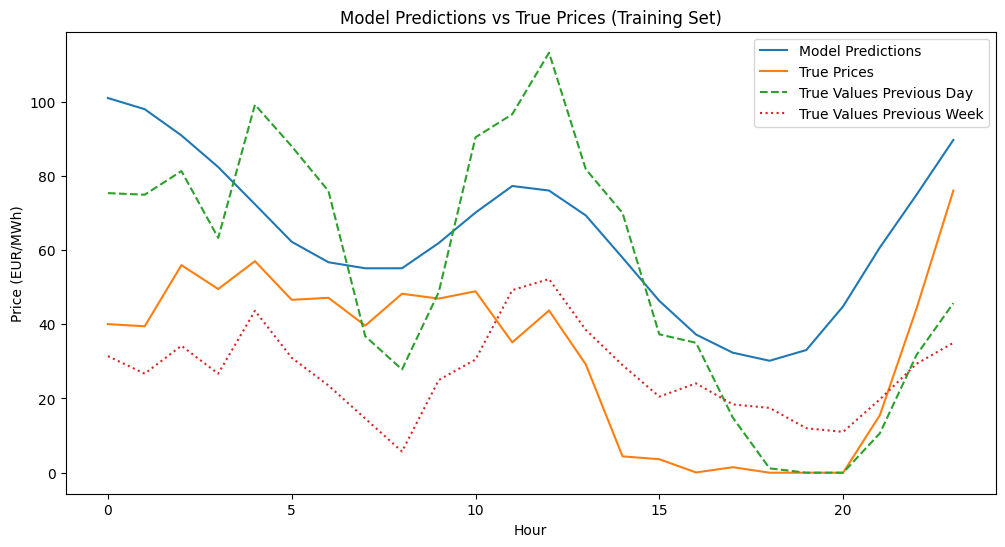

In [35]:

#Plot the first 24 hours of the training set
idx=np.random.randint(168, len(y_train_norm)-1)
plt.figure(figsize=(12,6))
plt.plot(eval_res_train['predictions'][idx], label='Model Predictions')
plt.plot(y_train[idx], label='True Prices')
plt.plot(y1d_train[idx], label='True Values Previous Day', linestyle='--')
plt.plot(y7d_train[idx], label='True Values Previous Week', linestyle=':')
plt.title('Model Predictions vs True Prices (Training Set)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()  

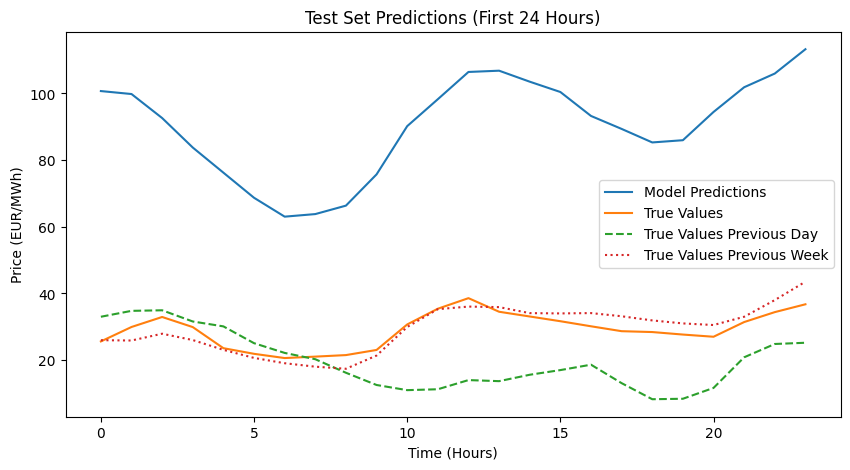

In [36]:
#Plot on the forst 24 hours of the test set
idx=np.random.randint(168, len(y_test)-1)

plt.figure(figsize=(10, 5))
plt.plot(eval_res_test['predictions'][idx], label='Model Predictions')
plt.plot(y_test[idx], label='True Values')
plt.plot(y1d_test[idx], label='True Values Previous Day', linestyle='--')
plt.plot(y7d_test[idx], label='True Values Previous Week', linestyle=':')
plt.title('Test Set Predictions (First 24 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [39]:
def objective(trial):
    # --- Hyperparameters to tune ---
    hidden_size=trial.suggest_categorical("hidden_size", [64, 128, 256])
    num_layers=trial.suggest_categorical("num_layers", [1, 2, 3])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs = 15  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        Xrt_train_norm, Xda_train_norm, y_train_norm, Xrt_dev_norm, Xda_dev_norm, y_dev_norm,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        verbose_freq=10
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, Xrt_dev_norm, Xda_dev_norm, y_dev_norm, y1d_dev, y7d_dev,stats_dict,batch_size=batch_size, device=device)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE_1d"]  # smaller = better
    rmae_7d=metrics["rMAE_7d"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=20, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")



[I 2025-11-29 02:35:23,014] A new study created in memory with name: no-name-af06b672-1c9b-4cd0-b76e-acd92e4f766a
/tmp/ipykernel_3456/23356513.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/tmp/ipykernel_3456/23356513.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_3456/23356513.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = trial.sug

Model:
RNN(
  (lstm): LSTM(10, 256, batch_first=True)
  (dropout): Dropout(p=0.27176936449976974, inplace=False)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
  (bn_lstm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_fc1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.0980476216221739)
    (2): Dropout(p=0.27176936449976974, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.0980476216221739)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.002162598793801221
    maximize: F

[I 2025-11-29 02:36:33,316] Trial 0 finished with values: [81.65456550678671, 0.9185698963190936, 3.3936042147851824, 2.144970313306203] and parameters: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.27176936449976974, 'use_batchnorm': True, 'leaky_alpha': 0.0980476216221739, 'learning_rate': 0.002162598793801221, 'weight_decay': 0.00011595992509369921, 'l1_lambda': 1.8306183179307312e-06, 'batch_size': 128}.


MAE: 81.6546 | MAEm: 0.9186 | rMAE-1d: 3.3936 | rMAE-7d: 2.1450
Model:
RNN(
  (lstm): LSTM(10, 256, batch_first=True)
  (dropout): Dropout(p=0.39585391069987363, inplace=False)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.036910577043651596)
    (2): Dropout(p=0.39585391069987363, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.036910577043651596)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001158442763652834
    maximize: False
    weight_decay: 6.206424287066159e-06
)
Batch size: 128 Epochs: 15
Epoch 001 | Train MAE: 93.466352 | Val MAE: 

[I 2025-11-29 02:37:45,341] Trial 1 finished with values: [84.01640026324384, 0.9451392656360038, 3.491763237913814, 2.2070129609658036] and parameters: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.39585391069987363, 'use_batchnorm': False, 'leaky_alpha': 0.036910577043651596, 'learning_rate': 0.0001158442763652834, 'weight_decay': 6.206424287066159e-06, 'l1_lambda': 3.813551152216529e-07, 'batch_size': 128}.


...

MAE: 78.1313 | MAEm: 0.8789 | rMAE-1d: 3.2472 | rMAE-7d: 2.0524
Model:
RNN(
  (lstm): LSTM(10, 256, num_layers=2, batch_first=True, dropout=0.4882207235561474)
  (dropout): Dropout(p=0.4882207235561474, inplace=False)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.18586199523079316)
    (2): Dropout(p=0.4882207235561474, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.18586199523079316)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2.533314486373006e-05
    maximize: False
    weight_decay: 9.754189416766674e-06
)
Batch size: 64 Epochs: 15
Epoch 0

[I 2025-11-29 02:42:17,991] Trial 3 finished with values: [93.96840034971117, 1.0570939081089237, 3.9053732942452144, 2.468440409768026] and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4882207235561474, 'use_batchnorm': False, 'leaky_alpha': 0.18586199523079316, 'learning_rate': 2.533314486373006e-05, 'weight_decay': 9.754189416766674e-06, 'l1_lambda': 0.00011772466350977875, 'batch_size': 64}.


MAE: 93.9684 | MAEm: 1.0571 | rMAE-1d: 3.9054 | rMAE-7d: 2.4684
Model:
RNN(
  (lstm): LSTM(10, 64, num_layers=3, batch_first=True, dropout=0.482692826946923)
  (dropout): Dropout(p=0.482692826946923, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=24, bias=True)
  (future_dense): Sequential(
    (0): Linear(in_features=216, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.08829522505456695)
    (2): Dropout(p=0.482692826946923, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.08829522505456695)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005252216934112447
    maximize: False
    weight_decay: 6.68095205360917e-05
)
Batch size: 64 Epochs: 15
Epoch 001 | Train 

[W 2025-11-29 02:42:44,147] Trial 4 failed with parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.482692826946923, 'use_batchnorm': False, 'leaky_alpha': 0.08829522505456695, 'learning_rate': 0.0005252216934112447, 'weight_decay': 6.68095205360917e-05, 'l1_lambda': 0.0002219836821010241, 'batch_size': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/pytorch/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3456/23356513.py", line 15, in objective
    MODEL, train_hist, val_hist = run_full_train(
                                  ^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3456/3698681813.py", line 101, in run_full_train
    loss.backward()
  File "/opt/pytorch/lib/python3.12/site-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/opt/pytorch/lib/python3.12/site-packag

KeyboardInterrupt: 

In [ ]:
#Hyperparameter search
dropout = np.linspace(0.0, 0.5, 5)
lr = np.logspace(-5, -3, 5)
results = {}

for d in dropout:
    for learning_rate in lr:
        print(f"Training with dropout {d} and learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train, y_train_FR, X_dev, y_dev_FR,
            dropout = d,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 20,
            verbose_freq = 10
        )

        print("Evaluating on dev set:")
        eval_res = evaluate_model(
            model, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, 
            std_FR, mean_FR, device=device
        )
        print("\n")

        # store clean results
        results[(d, learning_rate)] = {
            "MAE": eval_res["MAE"],
            "MAEm": eval_res["MAEm"],
            "rMAE1": eval_res["rMAE (1 day)"],
            "rMAE7": eval_res["rMAE (7 days)"],
        }

# --- find best ---
min_mae = min(v["MAE"] for v in results.values())
min_maem = min(v["MAEm"] for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae = [k for k,v in results.items() if v["MAE"] == min_mae]
best_configs_maem = [k for k,v in results.items() if v["MAEm"] == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print(f"Best configurations for minimum MAE ({min_mae}): {best_configs_mae}")
print(f"Best configurations for minimum MAEm ({min_maem}): {best_configs_maem}")
print(f"Best configurations for minimum rMAE (1 day) ({min_rmae1}): {best_configs_rmae1}")
print(f"Best configurations for minimum rMAE (7 days) ({min_rmae7}): {best_configs_rmae7}")

In [ ]:
# ...existing code...
# This cell: build short labels, fill matrices, find minima and plot grid with metric-text colored per-minimum
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()})   # dropout values
lrs   = sorted({k[1] for k in results.keys()})   # learning rates


# metrics to show in each grid cell
metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]


# prepare matrices for each metric and multiline text for annotations
metrics_mats = {mk: np.full((len(archs), len(lrs)), np.nan, dtype=float) for mk in metric_keys}
cell_text = np.full((len(archs), len(lrs)), "", dtype=object)

for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and any(k in v for k in metric_keys):
        ev = v
    else:
        ev = None

    i = archs.index(arch)   # arch is already a float
    j = lrs.index(lr)       # lr is also a float

    if ev is None:
        cell_text[i, j] = "no eval"
        continue

    # use short, unambiguous labels so rMAE (1 day) / (7 days) are distinct in the cell text
    short_labels = {
        "MAE": "MAE",
        "MAEm": "MAEm",
        "rMAE1": "rMAE1",
        "rMAE7": "rMAE7",
    }

    parts = []
    for mk in metric_keys:
        val = ev.get(mk, np.nan)
        try:
            valf = float(val)
        except Exception:
            valf = np.nan
        metrics_mats[mk][i, j] = valf
        lab = short_labels.get(mk, mk.split()[0])
        parts.append(f"{lab}:{valf:.3f}" if not np.isnan(valf) else f"{lab}:nan")
    cell_text[i, j] = "\n".join(parts)

# --- find minimum positions for each metric (ignore NaNs) ---
min_positions = {}
for mk in metric_keys:
    mat = metrics_mats[mk]
    if np.all(np.isnan(mat)):
        min_positions[mk] = []
    else:
        min_val = np.nanmin(mat)
        # positions as (row, col) tuples
        pos = list(zip(*np.where(np.isclose(mat, min_val, atol=1e-12))))
        min_positions[mk] = pos

# --- Plot grid WITHOUT heatmap, annotate every cell with 4 metrics and highlight minima ---
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8 + 0.6 * len(archs)))
ax.set_xlim(-0.5, len(lrs) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)  # origin at top to match previous layout
# set_xticks / set_yticks do not accept fontsize; set font size via set_xticklabels / set_yticklabels
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{lr:.0e}" for lr in lrs], fontsize=16, rotation=45)
ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=16)
ax.set_xlabel("learning rate", fontsize=16)
ax.set_ylabel("dropout", fontsize=16)

# draw light grid lines
for x in range(len(lrs) + 1):
    ax.axvline(x - 0.5, color='lightgray', linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color='lightgray', linewidth=0.8)

# colors for each metric's minima (kept distinct)
colors = ['red', 'blue', 'green', 'purple']
metric_colors = {mk: colors[idx % len(colors)] for idx, mk in enumerate(metric_keys)}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys]

# annotate every cell with the 4 metrics as separate text items, color the line if it's a metric minimum
# vertical offsets inside a cell (from top to bottom rows use negative->positive relative to center)
y_offsets = [-0.35, -0.12, 0.12, 0.35]

for i in range(len(archs)):
    for j in range(len(lrs)):
        ev_lines = cell_text[i, j].split("\n") if (cell_text[i, j] and isinstance(cell_text[i, j], str)) else []
        if not ev_lines:
            ax.text(j, i, "no eval", ha='center', va='center', fontsize=7, color='gray')
            continue

        # for each metric place a separate text entry with its own color (default black)
        for k, mk in enumerate(metric_keys):
            line = ev_lines[k] if k < len(ev_lines) else ""
            if not line:
                continue
            # default color
            txt_color = 'black'
            # if this (i,j) is one of the minima positions for this metric, color the metric text
            if (i, j) in min_positions.get(mk, []):
                txt_color = metric_colors[mk]
            ax.text(j, i + y_offsets[k], line, ha='center', va='center', fontsize=16, color=txt_color)

# place legend outside plot to the right
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, borderaxespad=0.1)

plt.tight_layout()
plt.savefig("metrics_grid_minima_text_colored.png", bbox_inches='tight')
plt.show()
# ...existing code...